In [ ]:
!pip install lightgbm --quiet

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings, os
from datetime import date

warnings.filterwarnings("ignore")

In [ ]:
# ── Mount Drive ─────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR = "/content/drive/My Drive/Colab Notebooks/Warehouse_Order_Forecast"
WH_ID    = "WH001"
print(f"📂 {DATA_DIR}\n")


Mounted at /content/drive
📂 /content/drive/My Drive/Colab Notebooks/Warehouse_Order_Forecast



In [ ]:
# ══════════════════════════════════════════════════════════════
# 1. LOAD & AGGREGATE  (daily grain per SKU, WH001 only)
# ══════════════════════════════════════════════════════════════
print("📥 Loading CSVs …")
hdr = pd.read_csv(f"{DATA_DIR}/fact_orders_header.csv",
                  usecols=["order_id","order_date","warehouse_id"],
                  parse_dates=["order_date"])
hdr = hdr[hdr["warehouse_id"] == WH_ID]
valid_ids = set(hdr["order_id"])

chunks = []
for chunk in pd.read_csv(f"{DATA_DIR}/fact_orders_detail.csv",
                          usecols=["order_id","product_id","ordered_qty"],
                          chunksize=500_000):
    chunks.append(chunk[chunk["order_id"].isin(valid_ids)])
detail = pd.concat(chunks, ignore_index=True)

df = detail.merge(hdr[["order_id","order_date"]], on="order_id")
daily = (df.groupby(["order_date","product_id"], as_index=False)["ordered_qty"]
           .sum()
           .rename(columns={"ordered_qty":"total_qty"}))
daily["order_date"] = pd.to_datetime(daily["order_date"])
daily = daily.sort_values(["product_id","order_date"]).reset_index(drop=True)

all_skus     = daily["product_id"].unique()
full_date_idx = pd.date_range(daily["order_date"].min(),
                               daily["order_date"].max(), freq="D")
print(f"   ✔ {len(daily):,} daily rows  |  {len(all_skus):,} SKUs")



📥 Loading CSVs …
   ✔ 388,601 daily rows  |  600 SKUs


In [ ]:
# ══════════════════════════════════════════════════════════════
# 2. BUILD HISTORICAL DOW × MONTH BASELINE  (per SKU)
#    For each SKU, compute:
#      • median qty  for (month, day_of_week) across ALL history
#      • p25 / p75   for the prediction band
# ══════════════════════════════════════════════════════════════
print("\n📐 Computing DOW × Month baseline statistics …")

daily["month"]       = daily["order_date"].dt.month
daily["day_of_week"] = daily["order_date"].dt.dayofweek   # 0=Mon

# Aggregate: for each SKU × month × DOW → median, p25, p75
baseline = (
    daily.groupby(["product_id","month","day_of_week"])["total_qty"]
    .agg(
        baseline_median="median",
        baseline_p25=lambda x: np.percentile(x, 25),
        baseline_p75=lambda x: np.percentile(x, 75),
    )
    .reset_index()
)
print(f"   ✔ Baseline table: {len(baseline):,} rows")



📐 Computing DOW × Month baseline statistics …
   ✔ Baseline table: 50,383 rows


In [ ]:
# ══════════════════════════════════════════════════════════════
# 3. FEATURE ENGINEERING  (for LightGBM residual model)
#    Target = actual − baseline_median  →  model learns the
#    systematic deviation from the DOW/seasonal average.
#    Lags are computed on the RESIDUAL, not raw qty, so
#    near-zero recent history won't drag forecasts down.
# ══════════════════════════════════════════════════════════════
print("\n🔧 Engineering residual features …")

LAG_DAYS  = [7, 14, 21]
ROLL_WINS = [7, 14]

feat_frames = []
for sku in all_skus:
    sub = (
        daily[daily["product_id"] == sku]
        .set_index("order_date")[["total_qty","month","day_of_week"]]
        .reindex(full_date_idx)
        .fillna({"total_qty": 0})
        .ffill()           # forward-fill month/dow for reindexed dates
        .reset_index()
        .rename(columns={"index":"order_date"})
    )
    sub["product_id"]  = sku
    sub["month"]       = sub["order_date"].dt.month
    sub["day_of_week"] = sub["order_date"].dt.dayofweek

    # Attach baseline median for each row
    sub = sub.merge(baseline[["product_id","month","day_of_week",
                               "baseline_median","baseline_p25","baseline_p75"]],
                    on=["product_id","month","day_of_week"], how="left")

    # Residual  =  actual  −  DOW/season average
    sub["residual"] = sub["total_qty"] - sub["baseline_median"].fillna(0)

    # Calendar features
    sub["year"]        = sub["order_date"].dt.year
    sub["day_of_year"] = sub["order_date"].dt.dayofyear
    sub["week"]        = sub["order_date"].dt.isocalendar().week.astype(int)
    sub["is_weekend"]  = (sub["day_of_week"] >= 5).astype(int)

    # Lag + rolling on RESIDUAL
    for lag in LAG_DAYS:
        sub[f"lag_{lag}"] = sub["residual"].shift(lag)
    for win in ROLL_WINS:
        sub[f"roll_{win}"] = sub["residual"].shift(1).rolling(win).mean()

    feat_frames.append(sub)

features = pd.concat(feat_frames, ignore_index=True).dropna()
print(f"   ✔ Feature matrix: {len(features):,} rows × {features.shape[1]} cols")



🔧 Engineering residual features …
   ✔ Feature matrix: 863,708 rows × 18 cols


In [ ]:
# ══════════════════════════════════════════════════════════════
# 4. TRAIN / TEST  +  SAVE CSVs
# ══════════════════════════════════════════════════════════════
FEAT_COLS = (
    ["day_of_week","month","day_of_year","year","week","is_weekend",
     "baseline_median","baseline_p25","baseline_p75"]
    + [f"lag_{l}"  for l in LAG_DAYS]
    + [f"roll_{w}" for w in ROLL_WINS]
)
TARGET = "residual"

cutoff   = features["order_date"].max() - pd.Timedelta(days=90)
train_df = features[features["order_date"] <= cutoff]
test_df  = features[features["order_date"] >  cutoff]

train_df[["order_date","product_id"] + FEAT_COLS + [TARGET,"total_qty"]]\
    .to_csv(f"{DATA_DIR}/lgbm_anchored_train.csv", index=False)
test_df[["order_date","product_id"]  + FEAT_COLS + [TARGET,"total_qty"]]\
    .to_csv(f"{DATA_DIR}/lgbm_anchored_test.csv",  index=False)
print(f"\n   💾 Saved lgbm_anchored_train.csv & lgbm_anchored_test.csv")
print(f"   Train: {len(train_df):,}  |  Test: {len(test_df):,}")


# ══════════════════════════════════════════════════════════════
# 5. TRAIN LIGHTGBM  (on residuals)
# ══════════════════════════════════════════════════════════════
print("\n🚀 Training LightGBM on residuals …")

params = dict(
    objective="regression", metric="rmse",
    learning_rate=0.05, num_leaves=63,
    min_child_samples=20, feature_fraction=0.8,
    bagging_fraction=0.8, bagging_freq=5,
    n_estimators=500, verbose=-1, random_state=42,
)
model = lgb.LGBMRegressor(**params)
model.fit(
    train_df[FEAT_COLS], train_df[TARGET],
    eval_set=[(test_df[FEAT_COLS], test_df[TARGET])],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)],
)

test_pred_resid = model.predict(test_df[FEAT_COLS])
test_pred_qty   = test_pred_resid + test_df["baseline_median"].values
actual_qty      = test_df["total_qty"].values
rmse = np.sqrt(np.mean((test_pred_qty - actual_qty)**2))
mae  = np.mean(np.abs(test_pred_qty  - actual_qty))
print(f"   📈 Test RMSE: {rmse:.2f}   MAE: {mae:.2f}")




   💾 Saved lgbm_anchored_train.csv & lgbm_anchored_test.csv
   Train: 809,737  |  Test: 53,971

🚀 Training LightGBM on residuals …
[100]	valid_0's rmse: 24.2943
   📈 Test RMSE: 24.29   MAE: 18.08


In [ ]:
# ══════════════════════════════════════════════════════════════
# 6. RECURSIVE 7-DAY FORECAST  — anchored + residual
# ══════════════════════════════════════════════════════════════
print("\n🔮 Generating 7-day anchored forecast …")

today          = pd.Timestamp(date.today())
forecast_dates = pd.date_range(today + pd.Timedelta(days=1), periods=7, freq="D")
print(f"   Window: {forecast_dates[0].date()} → {forecast_dates[-1].date()}")

# Per-SKU residual history dict for lag lookups
resid_hist = {}
for sku in all_skus:
    sub = features[features["product_id"] == sku].set_index("order_date")["residual"]
    resid_hist[sku] = sub.reindex(
        pd.date_range(features["order_date"].min(),
                      features["order_date"].max(), freq="D"),
        fill_value=0
    ).copy()

# Baseline lookup dict
base_lookup = baseline.set_index(["product_id","month","day_of_week"])

forecast_rows = []

for fdate in forecast_dates:
    month = fdate.month
    dow   = fdate.dayofweek

    for sku in all_skus:
        rh = resid_hist[sku]

        # Lags on residual
        lags = {f"lag_{l}":  rh.get(fdate - pd.Timedelta(days=l), 0)
                for l in LAG_DAYS}
        rolls = {f"roll_{w}": np.mean([rh.get(fdate - pd.Timedelta(days=d), 0)
                                       for d in range(1, w+1)])
                 for w in ROLL_WINS}

        # Baseline stats for this SKU / month / DOW
        key = (sku, month, dow)
        if key in base_lookup.index:
            b_med = base_lookup.loc[key, "baseline_median"]
            b_p25 = base_lookup.loc[key, "baseline_p25"]
            b_p75 = base_lookup.loc[key, "baseline_p75"]
        else:
            b_med = b_p25 = b_p75 = 0.0

        row = dict(
            day_of_week=dow, month=month,
            day_of_year=fdate.dayofyear, year=fdate.year,
            week=fdate.isocalendar()[1], is_weekend=int(dow >= 5),
            baseline_median=b_med, baseline_p25=b_p25, baseline_p75=b_p75,
            **lags, **rolls
        )

        pred_resid = model.predict(pd.DataFrame([row])[FEAT_COLS])[0]
        pred_qty   = max(0, b_med + pred_resid)

        # Prediction interval = baseline band ± model residual std
        resid_std  = features[features["product_id"] == sku]["residual"].std()
        pi_lo = max(0, b_p25 + pred_resid - 0.5 * resid_std)
        pi_hi = max(0, b_p75 + pred_resid + 0.5 * resid_std)

        forecast_rows.append({
            "forecast_date": fdate.date(),
            "product_id":    sku,
            "baseline":      round(b_med, 1),
            "predicted_qty": round(pred_qty, 1),
            "pi_low":        round(pi_lo, 1),
            "pi_high":       round(pi_hi, 1),
        })

        # Feed back into residual history
        resid_hist[sku][fdate] = pred_resid

forecast_df = pd.DataFrame(forecast_rows)
forecast_df.to_csv(f"{DATA_DIR}/lgbm_anchored_forecast_7day.csv", index=False)
print(f"   ✔ Saved lgbm_anchored_forecast_7day.csv  ({len(forecast_df):,} rows)")

# Warehouse-level summary
wh_sum = (forecast_df.groupby("forecast_date")
          [["predicted_qty","pi_low","pi_high"]].sum().reset_index())
print("\n   WH001 — 7-Day Forecast (all SKUs summed):")
print(wh_sum.to_string(index=False))



🔮 Generating 7-day anchored forecast …
   Window: 2026-03-07 → 2026-03-13
   ✔ Saved lgbm_anchored_forecast_7day.csv  (4,200 rows)

   WH001 — 7-Day Forecast (all SKUs summed):
forecast_date  predicted_qty  pi_low  pi_high
   2026-03-07        15594.9  3084.6  30972.8
   2026-03-08        15407.7  3232.1  30940.8
   2026-03-09        15194.8  3284.9  29986.6
   2026-03-10        14916.2  2913.3  30180.5
   2026-03-11        14877.5  2586.3  29867.1
   2026-03-12        14080.1  2353.0  29033.4
   2026-03-13        13575.1  2328.6  29014.7


In [ ]:
# ══════════════════════════════════════════════════════════════
# 7. TOP-3 SKUs
# ══════════════════════════════════════════════════════════════
top3 = (daily.groupby("product_id")["total_qty"]
        .sum().nlargest(3).index.tolist())
print(f"\n🏆 Top-3 SKUs: {top3}")


🏆 Top-3 SKUs: ['SKU-0084', 'SKU-0009', 'SKU-0115']



🎨 Rendering charts …


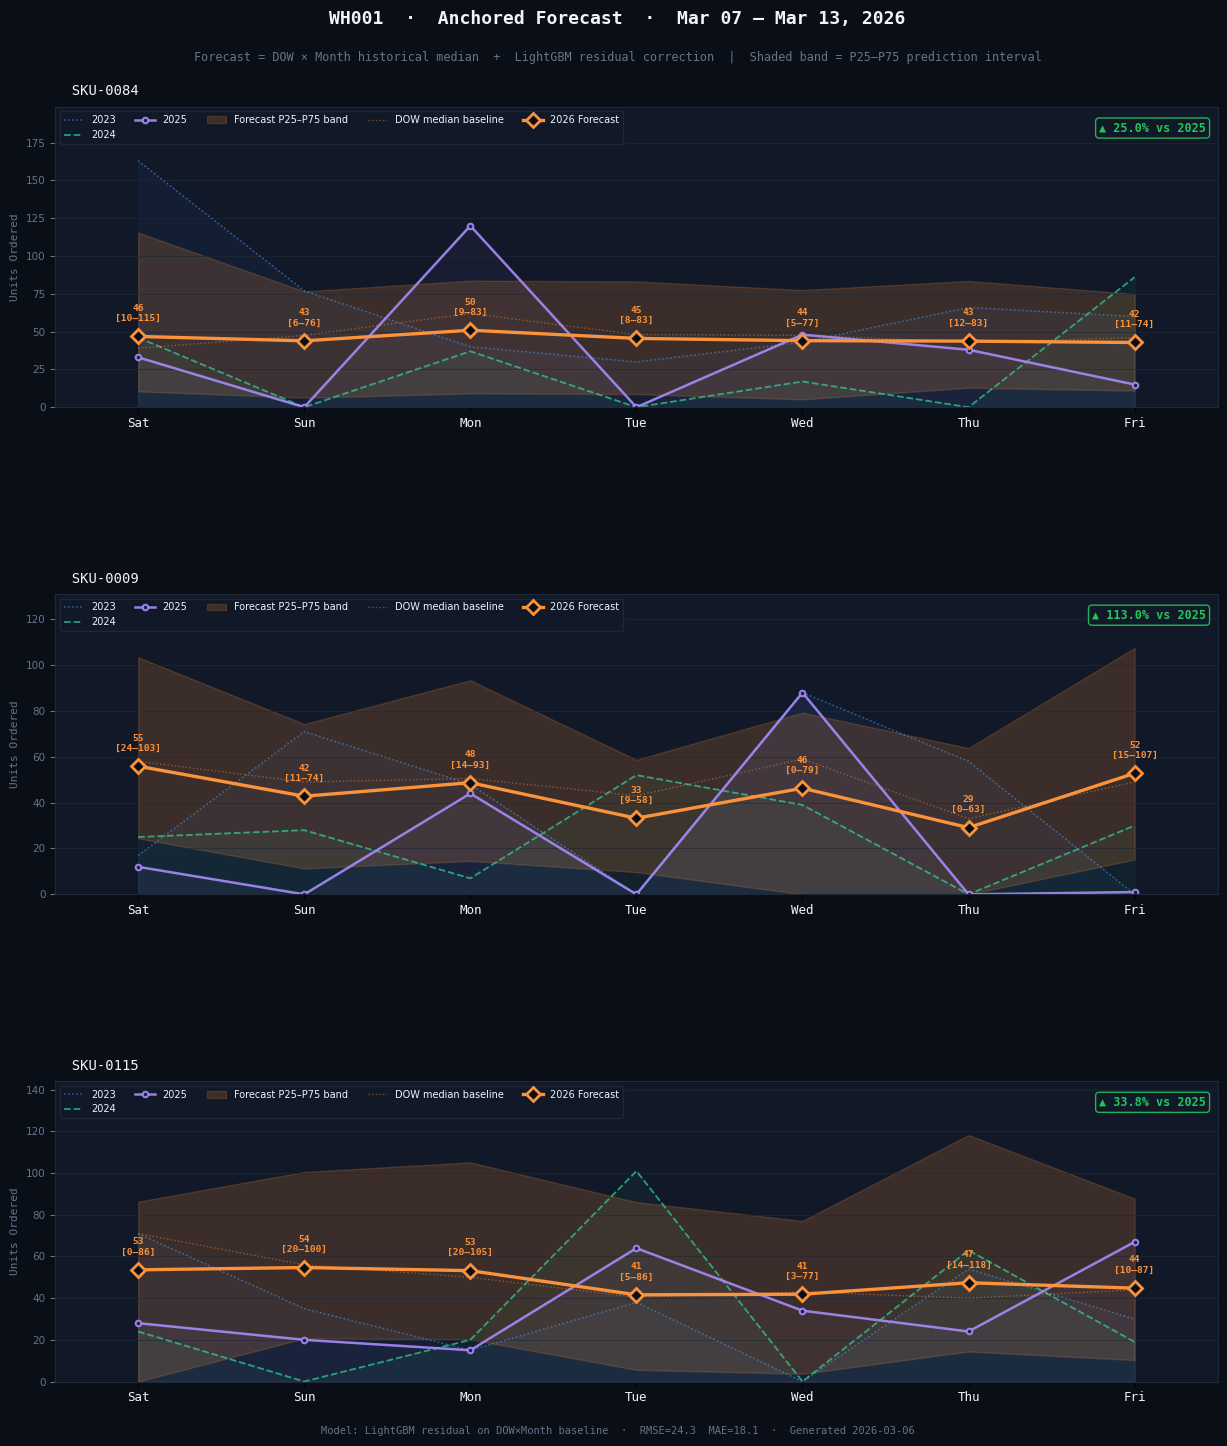


💾 Saved: wh001_anchored_forecast_chart.png

══════════════════════════════════════════════════════════════
✅  DONE
══════════════════════════════════════════════════════════════
   lgbm_anchored_train.csv                          89.1 MB
   lgbm_anchored_test.csv                            6.0 MB
   lgbm_anchored_forecast_7day.csv                   0.2 MB
   wh001_anchored_forecast_chart.png                 0.4 MB


In [ ]:
# ══════════════════════════════════════════════════════════════
# 8. CHART  — YoY same-week + anchored forecast + PI band
# ══════════════════════════════════════════════════════════════
print("\n🎨 Rendering charts …")

DARK_BG  = "#0a0e17"
PANEL_BG = "#111827"
GRID_COL = "#1f2937"
TEXT_COL = "#f1f5f9"
MUTED    = "#64748b"

YEAR_STYLES = {
    2023: dict(color="#4a9eff", lw=1.1, ls=":",  alpha=0.55),
    2024: dict(color="#34d399", lw=1.3, ls="--", alpha=0.70),
    2025: dict(color="#a78bfa", lw=1.8, ls="-",  alpha=0.90, marker="o"),
    2026: dict(color="#fb923c", lw=2.4, ls="-",  alpha=1.00, marker="D"),
}

fore_start = forecast_df["forecast_date"].min()
fore_end   = forecast_df["forecast_date"].max()
if not isinstance(fore_start, pd.Timestamp):
    fore_start = pd.Timestamp(fore_start)
    fore_end   = pd.Timestamp(fore_end)

COMPARE_YEARS = [2023, 2024, 2025]

def same_week_slice(sku, year):
    try:
        s = pd.Timestamp(year, fore_start.month, fore_start.day)
        e = pd.Timestamp(year, fore_end.month,   fore_end.day)
    except ValueError:
        return pd.Series(dtype=float)
    mask = ((daily["product_id"] == sku) &
            (daily["order_date"] >= s) & (daily["order_date"] <= e))
    return (daily[mask].set_index("order_date")["total_qty"]
            .reindex(pd.date_range(s, e, freq="D"), fill_value=0))

x_pos    = list(range(7))
dow_lbls = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_off  = fore_start.dayofweek
x_lbls   = dow_lbls[dow_off:] + dow_lbls[:dow_off]

fig, axes = plt.subplots(3, 1, figsize=(15, 15), facecolor=DARK_BG)
fig.subplots_adjust(hspace=0.62, top=0.91, bottom=0.06)

fig.text(0.5, 0.965,
         f"WH001  ·  Anchored Forecast  ·  "
         f"{fore_start.strftime('%b %d')} – {pd.Timestamp(fore_end).strftime('%b %d, %Y')}",
         ha="center", color=TEXT_COL, fontsize=13,
         fontweight="bold", fontfamily="monospace")
fig.text(0.5, 0.940,
         "Forecast = DOW × Month historical median  +  LightGBM residual correction  |  "
         "Shaded band = P25–P75 prediction interval",
         ha="center", color=MUTED, fontsize=8.5, fontfamily="monospace")

for ax, sku in zip(axes, top3):
    ax.set_facecolor(PANEL_BG)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID_COL)

    all_vals = []

    # ── Historical years ─────────────────────────────────────
    for yr in COMPARE_YEARS:
        sl = same_week_slice(sku, yr)
        if sl.empty: continue
        v  = sl.values;  all_vals.extend(v)
        st = YEAR_STYLES[yr]
        kw = dict(color=st["color"], linewidth=st["lw"],
                  linestyle=st["ls"], alpha=st["alpha"])
        ax.plot(x_pos[:len(v)], v, **kw,
                marker=st.get("marker",""), markersize=4,
                markerfacecolor=PANEL_BG, markeredgewidth=1.5,
                label=str(yr))
        ax.fill_between(x_pos[:len(v)], v, alpha=0.05, color=st["color"])

    # ── 2026 Forecast + PI band ───────────────────────────────
    sf = (forecast_df[forecast_df["product_id"] == sku]
          .sort_values("forecast_date"))
    fv   = sf["predicted_qty"].values
    f_lo = sf["pi_low"].values
    f_hi = sf["pi_high"].values
    all_vals.extend(fv); all_vals.extend(f_hi)

    st = YEAR_STYLES[2026]

    # PI shaded band
    ax.fill_between(x_pos[:len(fv)], f_lo, f_hi,
                    color=st["color"], alpha=0.18,
                    label="Forecast P25–P75 band")

    # Baseline dashes (the raw DOW median)
    base_vals = sf["baseline"].values
    ax.plot(x_pos[:len(base_vals)], base_vals,
            color=st["color"], linewidth=1.0,
            linestyle=":", alpha=0.45, label="DOW median baseline")

    # Forecast line
    ax.plot(x_pos[:len(fv)], fv,
            color=st["color"], linewidth=st["lw"],
            linestyle=st["ls"], alpha=st["alpha"],
            marker=st["marker"], markersize=7,
            markerfacecolor=DARK_BG, markeredgewidth=2,
            zorder=5, label="2026 Forecast")

    # Value + interval annotations
    for xi, (fval, lo, hi) in enumerate(zip(fv, f_lo, f_hi)):
        ax.annotate(
            f"{int(fval)}\n[{int(lo)}–{int(hi)}]",
            xy=(xi, fval), xytext=(0, 11),
            textcoords="offset points", ha="center",
            color=st["color"], fontsize=6.8, fontfamily="monospace",
            fontweight="bold",
        )

    # YoY badge
    sl25 = same_week_slice(sku, 2025)
    if not sl25.empty and sl25.sum() > 0:
        pct = (fv.sum() - sl25.sum()) / sl25.sum() * 100
        bc  = "#22c55e" if pct >= 0 else "#ef4444"
        ax.text(0.99, 0.95, f"{'▲' if pct>=0 else '▼'} {abs(pct):.1f}% vs 2025",
                transform=ax.transAxes, ha="right", va="top",
                color=bc, fontsize=8.5, fontfamily="monospace", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL_BG,
                          edgecolor=bc, alpha=0.9))

    # Axis formatting
    ax.set_title(f"  {sku}", color=TEXT_COL, fontsize=10,
                 fontfamily="monospace", loc="left", pad=8)
    ax.set_xticks(x_pos[:len(fv)])
    ax.set_xticklabels(x_lbls[:len(fv)], color=TEXT_COL,
                       fontsize=9, fontfamily="monospace")
    ax.tick_params(axis="y", colors=MUTED, labelsize=7.5)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_ylabel("Units Ordered", color=MUTED, fontsize=8,
                  fontfamily="monospace")
    ax.grid(True, color=GRID_COL, linewidth=0.5, alpha=0.9, axis="y")
    ax.set_xlim(-0.5, 6.5)
    if all_vals:
        ax.set_ylim(0, max(all_vals) * 1.22)
    ax.legend(loc="upper left", fontsize=7, ncol=5,
              facecolor=PANEL_BG, edgecolor=GRID_COL,
              labelcolor=TEXT_COL, framealpha=0.9)

fig.text(0.5, 0.025,
         f"Model: LightGBM residual on DOW×Month baseline  ·  "
         f"RMSE={rmse:.1f}  MAE={mae:.1f}  ·  Generated {date.today()}",
         ha="center", color=MUTED, fontsize=7.5, fontfamily="monospace")

out = f"{DATA_DIR}/wh001_anchored_forecast_chart.png"
plt.savefig(out, bbox_inches="tight", facecolor=DARK_BG, dpi=150)
plt.show()
print(f"\n💾 Saved: wh001_anchored_forecast_chart.png")

# ── Output summary ───────────────────────────────────────────
print("\n" + "═"*62)
print("✅  DONE")
print("═"*62)
for f in ["lgbm_anchored_train.csv","lgbm_anchored_test.csv",
          "lgbm_anchored_forecast_7day.csv","wh001_anchored_forecast_chart.png"]:
    sz = os.path.getsize(f"{DATA_DIR}/{f}") / 1_048_576
    print(f"   {f:<45}  {sz:>6.1f} MB")